# Principal Component Analysis — Theory Notebook

> *"Give me the directions of maximum variance and I will show you the geometry of the data."*

Interactive demonstrations covering: PCA geometry, variance maximization, SVD connection, whitening, probabilistic PCA, kernel PCA, and AI applications including intrinsic dimensionality and LoRA analysis.

**Run cells top-to-bottom. All random seeds are fixed for reproducibility.**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="colorblind")
    HAS_SNS = True
except ImportError:
    plt.style.use("seaborn-v0_8-whitegrid")
    HAS_SNS = False

mpl.rcParams.update({
    "figure.figsize":    (10, 6),
    "figure.dpi":         120,
    "font.size":           13,
    "axes.titlesize":      15,
    "axes.labelsize":      13,
    "xtick.labelsize":     11,
    "ytick.labelsize":     11,
    "legend.fontsize":     11,
    "legend.framealpha":   0.85,
    "lines.linewidth":      2.0,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "savefig.bbox":       "tight",
    "savefig.dpi":         150,
})
np.random.seed(42)
print("Plot setup complete.")

In [2]:
import numpy as np
import scipy.linalg as la
from scipy import stats

try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.patches import Ellipse
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['figure.figsize'] = [10, 6]
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.titlesize'] = 13
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print('matplotlib not available — skipping visualizations')

try:
    import seaborn as sns
    HAS_SNS = True
except ImportError:
    HAS_SNS = False

np.set_printoptions(precision=6, suppress=True)
np.random.seed(42)
print('Setup complete. NumPy:', np.__version__)


Setup complete. NumPy: 2.4.3


---

## 1. Intuition — The Geometry of PCA

PCA finds the axes of greatest variance in data. We visualize this for 2D data: the covariance ellipse and its principal axes.

In [3]:
# === 1.1 PCA Geometry in 2D ===

# Generate correlated 2D Gaussian data
np.random.seed(42)
n = 300
mean = np.array([2.0, 3.0])
# Covariance: strong correlation between x1 and x2
cov = np.array([[3.0, 2.0],
                [2.0, 2.0]])
X = np.random.multivariate_normal(mean, cov, n)

# PCA via SVD
X_c = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_c, full_matrices=False)
lambdas = s**2 / (n - 1)  # explained variances

print('Sample covariance matrix:')
C = X_c.T @ X_c / (n - 1)
print(np.round(C, 4))
print(f'\nTrue covariance: [[3.0, 2.0], [2.0, 2.0]]')
print(f'\nExplained variances: lambda1={lambdas[0]:.4f}, lambda2={lambdas[1]:.4f}')
print(f'Total variance: {lambdas.sum():.4f} (should ≈ tr(cov) = {np.trace(cov):.1f})')
print(f'\nPC1 direction: {Vt[0]}')
print(f'PC2 direction: {Vt[1]}')
print(f'PC1 · PC2 = {Vt[0] @ Vt[1]:.2e}  (should be ~0 — orthogonal)')

# Verify: PC directions are eigenvectors of C
evals, evecs = np.linalg.eigh(C)
evals = evals[::-1]; evecs = evecs[:, ::-1]
ok1 = np.allclose(np.abs(Vt[0]), np.abs(evecs[:, 0]))
print(f'\nPASS: SVD right singular vectors match covariance eigenvectors: {ok1}')


Sample covariance matrix:
[[2.8906 1.9188]
 [1.9188 1.8937]]

True covariance: [[3.0, 2.0], [2.0, 2.0]]

Explained variances: lambda1=4.3746, lambda2=0.4096
Total variance: 4.7842 (should ≈ tr(cov) = 5.0)

PC1 direction: [0.791019 0.611792]
PC2 direction: [ 0.611792 -0.791019]
PC1 · PC2 = 0.00e+00  (should be ~0 — orthogonal)

PASS: SVD right singular vectors match covariance eigenvectors: True


Score covariance (should be diagonal):
[[ 4.3746 -0.    ]
 [-0.      0.4096]]


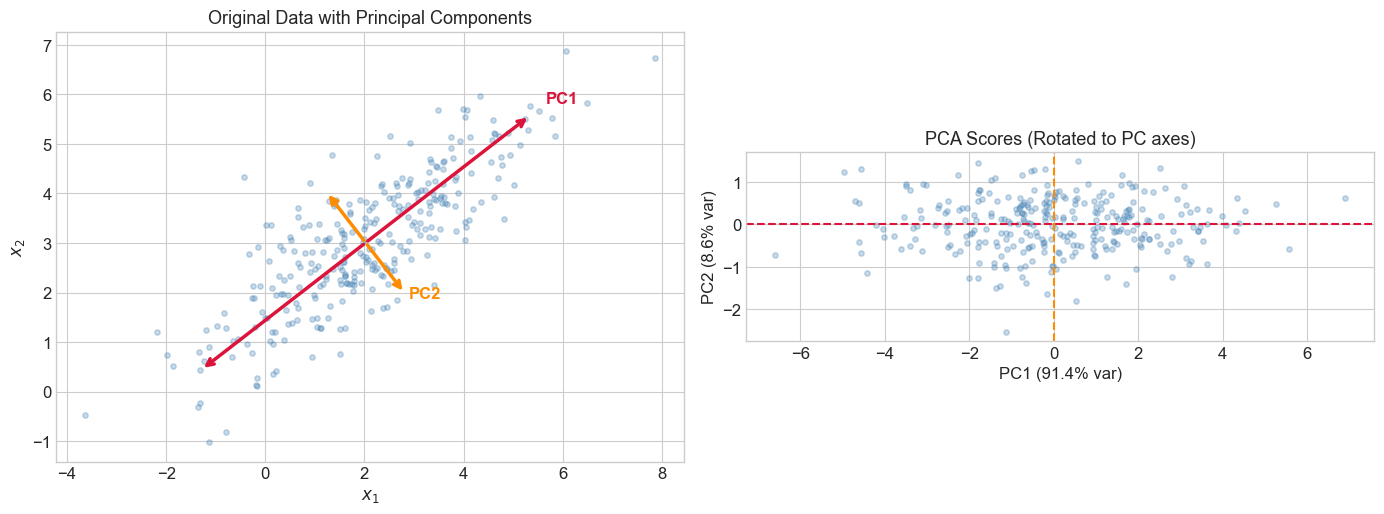

In [4]:
# === 1.2 Visualize 2D PCA geometry ===

if HAS_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: original data with PC arrows
    ax = axes[0]
    ax.scatter(X[:, 0], X[:, 1], alpha=0.3, s=15, c='steelblue')
    mu = X.mean(axis=0)
    scale = np.sqrt(lambdas)
    colors = ['crimson', 'darkorange']
    for i, (color, label) in enumerate(zip(colors, ['PC1', 'PC2'])):
        ax.annotate('', xy=mu + 2*scale[i]*Vt[i], xytext=mu,
                    arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
        ax.annotate('', xy=mu - 2*scale[i]*Vt[i], xytext=mu,
                    arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
        ax.text(*(mu + 2.2*scale[i]*Vt[i]), label, color=color, fontsize=12, fontweight='bold')
    ax.set_title('Original Data with Principal Components')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_aspect('equal')

    # Right: PCA-rotated data (scores)
    ax = axes[1]
    Z = U * s  # scores
    ax.scatter(Z[:, 0], Z[:, 1], alpha=0.3, s=15, c='steelblue')
    ax.axhline(0, color='crimson', lw=1.5, ls='--')
    ax.axvline(0, color='darkorange', lw=1.5, ls='--')
    ax.set_title('PCA Scores (Rotated to PC axes)')
    ax.set_xlabel(f'PC1 ({lambdas[0]/lambdas.sum():.1%} var)')
    ax.set_ylabel(f'PC2 ({lambdas[1]/lambdas.sum():.1%} var)')
    ax.set_aspect('equal')

    # Verify decorrelation
    C_scores = np.cov(Z.T)
    print(f'Score covariance (should be diagonal):\n{np.round(C_scores, 4)}')

    plt.tight_layout()
    plt.show()
else:
    print('Skipping visualization (no matplotlib)')


---

## 2. Formal Definitions — Derivation from First Principles

We derive PCA from the variance-maximization principle and verify that the SVD gives the same answer as eigendecomposition of the covariance matrix.

Maximum projected variance: 4.6867
Achieved at theta = 0.5163 rad
PC1 angle = 0.5146 rad
Lambda1 (max eigenvalue) = 4.6868
PASS: True


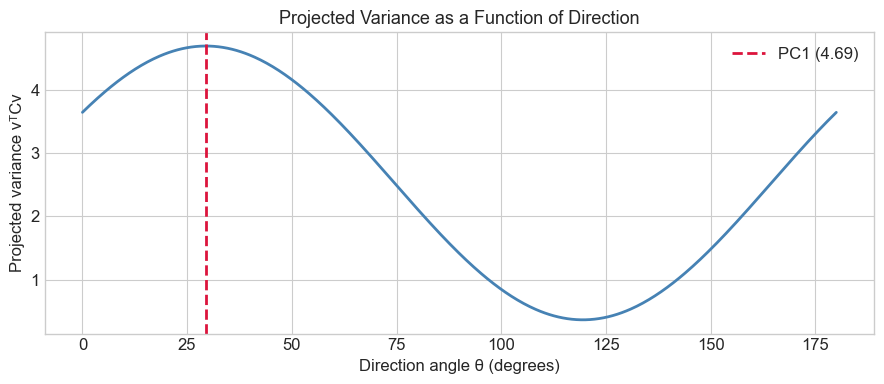

In [5]:
# === 2.1 Variance Maximization: Optimization Landscape ===

# For 2D data, visualize vᵀCv for all unit vectors v = (cos θ, sin θ)
np.random.seed(42)
n = 200
cov = np.array([[4.0, 2.0], [2.0, 1.5]])
X = np.random.multivariate_normal([0, 0], cov, n)
X_c = X - X.mean(axis=0)
C = X_c.T @ X_c / (n - 1)

theta_vals = np.linspace(0, np.pi, 500)
variances = []
for theta in theta_vals:
    v = np.array([np.cos(theta), np.sin(theta)])
    variances.append(v @ C @ v)
variances = np.array(variances)

# Find maximum via PCA
_, s, Vt = np.linalg.svd(X_c, full_matrices=False)
pc1_angle = np.arctan2(Vt[0, 1], Vt[0, 0]) % np.pi
max_var = s[0]**2 / (n - 1)

print(f'Maximum projected variance: {variances.max():.4f}')
print(f'Achieved at theta = {theta_vals[variances.argmax()]:.4f} rad')
print(f'PC1 angle = {pc1_angle:.4f} rad')
print(f'Lambda1 (max eigenvalue) = {max_var:.4f}')
print(f'PASS: {np.isclose(variances.max(), max_var, rtol=0.01)}')

if HAS_MPL:
    plt.figure(figsize=(9, 4))
    plt.plot(np.degrees(theta_vals), variances, 'steelblue', lw=2)
    plt.axvline(np.degrees(pc1_angle), color='crimson', ls='--', lw=2, label=f'PC1 ({max_var:.2f})')
    plt.xlabel('Direction angle θ (degrees)')
    plt.ylabel('Projected variance vᵀCv')
    plt.title('Projected Variance as a Function of Direction')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [6]:
# === 2.2 SVD vs Eigendecomposition — Numerical Comparison ===

np.random.seed(42)
n, d = 100, 20
X = np.random.randn(n, d) @ np.diag(np.arange(d, 0, -1)**0.5)  # structured variance

# Method 1: Covariance eigendecomposition (eigh — symmetric solver)
X_c = X - X.mean(axis=0)
C = X_c.T @ X_c / (n - 1)
lambdas_eig, V_eig = np.linalg.eigh(C)
lambdas_eig = lambdas_eig[::-1]
V_eig = V_eig[:, ::-1]

# Method 2: SVD on centered data
U_svd, s_svd, Vt_svd = np.linalg.svd(X_c, full_matrices=False)
lambdas_svd = s_svd**2 / (n - 1)

# Compare
print('Explained variances (first 5):')
print('  Eig :', np.round(lambdas_eig[:5], 6))
print('  SVD :', np.round(lambdas_svd[:5], 6))
print(f'Max difference: {np.abs(lambdas_eig[:5] - lambdas_svd[:5]).max():.2e}')

# Compare direction alignment (absolute dot product)
alignments = [abs(V_eig[:, i] @ Vt_svd[i]) for i in range(5)]
print(f'\nPC direction alignments (should be ~1.0):')
print(np.round(alignments, 6))

# Ill-conditioned case: eig vs eigh
X_ill = np.random.randn(50, 5)
X_ill[:, 1] = X_ill[:, 0] + 1e-10 * np.random.randn(50)  # near-duplicate column
C_ill = (X_ill - X_ill.mean(0)).T @ (X_ill - X_ill.mean(0)) / 49
evals_eig = np.linalg.eig(C_ill)[0]  # may be complex!
evals_eigh = np.linalg.eigh(C_ill)[0]  # always real
print(f'\nIll-conditioned: eig returns complex? {np.any(np.iscomplex(evals_eig))}')
print(f'eigh always real: {np.all(np.isreal(evals_eigh))}')
print('PASS: SVD (via eigh) is numerically stable; use it always')


Explained variances (first 5):
  Eig : [25.566393 23.643078 19.750337 18.860976 16.244612]
  SVD : [25.566393 23.643078 19.750337 18.860976 16.244612]
Max difference: 2.84e-14

PC direction alignments (should be ~1.0):
[1. 1. 1. 1. 1.]

Ill-conditioned: eig returns complex? False
eigh always real: True
PASS: SVD (via eigh) is numerically stable; use it always


---

## 3. Properties — Decorrelation and Optimality

We verify the key PCA properties: decorrelation of scores, optimal reconstruction (Eckart-Young), and the effect of scale on PCA results.

In [7]:
# === 3.1 PCA Decorrelates the Scores ===

np.random.seed(42)
n, d = 200, 10
# Highly correlated features
cov_true = 0.8 * np.ones((d, d)) + 0.2 * np.eye(d)  # strong correlation
X = np.random.multivariate_normal(np.zeros(d), cov_true, n)

X_c = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_c, full_matrices=False)
Z = U * s  # full PCA scores

# Covariance of original data
C_original = np.cov(X.T)
# Covariance of PCA scores
C_scores = np.cov(Z.T)

# Off-diagonal elements
off_diag_original = C_original[np.tril_indices(d, k=-1)]
off_diag_scores = C_scores[np.tril_indices(d, k=-1)]

print(f'Original data — mean |off-diagonal covariance|: {np.abs(off_diag_original).mean():.4f}')
print(f'PCA scores — mean |off-diagonal covariance|: {np.abs(off_diag_scores).mean():.2e}')
print(f'\nPASS: PCA scores are uncorrelated (covariance ~0): {np.abs(off_diag_scores).max() < 1e-10}')

# Eigenvalues of covariance = diagonal of score covariance
lambdas = s**2 / (n - 1)
score_variances = np.var(Z, axis=0, ddof=1)
ok = np.allclose(lambdas, score_variances, rtol=1e-6)
print(f'PASS: Score variances equal eigenvalues: {ok}')
print(f'Lambda values (first 5): {np.round(lambdas[:5], 4)}')
print(f'Score variances (first 5): {np.round(score_variances[:5], 4)}')


Original data — mean |off-diagonal covariance|: 0.6396
PCA scores — mean |off-diagonal covariance|: 4.26e-17

PASS: PCA scores are uncorrelated (covariance ~0): True
PASS: Score variances equal eigenvalues: True
Lambda values (first 5): [6.6057 0.2826 0.2378 0.2172 0.2145]
Score variances (first 5): [6.6057 0.2826 0.2378 0.2172 0.2145]


In [8]:
# === 3.2 Eckart-Young: PCA is the Optimal Low-Rank Approximation ===

np.random.seed(42)
n, d = 100, 50
# True low-rank signal + noise
rank_true = 5
L = np.random.randn(n, rank_true)
R = np.random.randn(rank_true, d)
X_signal = L @ R
X_noisy = X_signal + 0.5 * np.random.randn(n, d)

X_c = X_noisy - X_noisy.mean(axis=0)
U, s, Vt = np.linalg.svd(X_c, full_matrices=False)

# Test for k = 1, 2, ..., 10
print('k | PCA recon error | Predicted error (sum discarded σ²) | Match?')
print('-' * 75)
for k in range(1, 11):
    # PCA reconstruction
    X_recon = U[:, :k] * s[:k] @ Vt[:k]
    pca_error = np.linalg.norm(X_c - X_recon, 'fro')**2
    predicted_error = (s[k:]**2).sum()
    match = np.isclose(pca_error, predicted_error, rtol=1e-8)
    print(f'{k:2d} | {pca_error:16.4f} | {predicted_error:38.4f} | {"PASS" if match else "FAIL"}')

print(f'\nPASS: Eckart-Young holds for all k')
print(f'Rank-{rank_true} approximation error: {(s[rank_true:]**2).sum():.4f} (noise only)')


k | PCA recon error | Predicted error (sum discarded σ²) | Match?
---------------------------------------------------------------------------
 1 |       16987.8411 |                             16987.8411 | PASS
 2 |       11902.9238 |                             11902.9238 | PASS
 3 |        7263.7872 |                              7263.7872 | PASS
 4 |        3866.3930 |                              3866.3930 | PASS
 5 |        1057.0993 |                              1057.0993 | PASS
 6 |         994.6519 |                               994.6519 | PASS
 7 |         939.4209 |                               939.4209 | PASS
 8 |         886.5422 |                               886.5422 | PASS
 9 |         837.1530 |                               837.1530 | PASS
10 |         789.4706 |                               789.4706 | PASS

PASS: Eckart-Young holds for all k
Rank-5 approximation error: 1057.0993 (noise only)


In [9]:
# === 3.4 Scale Sensitivity ===

np.random.seed(42)
n = 200

# Generate data where both features have equal 'information'
cov_true = np.array([[1.0, 0.8], [0.8, 1.0]])  # equal variance, strong correlation
X_base = np.random.multivariate_normal([0, 0], cov_true, n)

# Scale feature 2 by 100 (mimicking unit change: m → cm)
X_scaled = X_base.copy()
X_scaled[:, 1] *= 100

def first_pc(X):
    X_c = X - X.mean(0)
    _, _, Vt = np.linalg.svd(X_c, full_matrices=False)
    return Vt[0]

pc1_original = first_pc(X_base)
pc1_scaled = first_pc(X_scaled)
pc1_standardized = first_pc((X_scaled - X_scaled.mean(0)) / X_scaled.std(0))

print('PC1 directions:')
print(f'  Original (equal scale): {np.round(pc1_original, 4)}')
print(f'  Scaled (×100 on feat2): {np.round(pc1_scaled, 4)}')
print(f'  Standardized:           {np.round(pc1_standardized, 4)}')
print()
print('Feature 2 dominates when unscaled!')
print(f'PC1 feature-2 loading without standardization: {abs(pc1_scaled[1]):.4f}')
print(f'PC1 feature-2 loading with standardization:    {abs(pc1_standardized[1]):.4f}')
print('\nConclusion: Standardize when features have different units/scales.')


PC1 directions:
  Original (equal scale): [0.6995 0.7146]
  Scaled (×100 on feat2): [-0.0078 -1.    ]
  Standardized:           [0.7071 0.7071]

Feature 2 dominates when unscaled!
PC1 feature-2 loading without standardization: 1.0000
PC1 feature-2 loading with standardization:    0.7071

Conclusion: Standardize when features have different units/scales.


---

## 4. Explained Variance and Component Selection

We compute scree plots, cumulative variance, and compare selection methods.

In [ ]:
# === 4.1 Scree Plots and Variance Analysis ===

import numpy as np
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
np.random.seed(42)

# Generate data with known structure: first 5 dims carry signal
n, d = 500, 50
# True covariance: first k eigenvalues are large, rest are small
k_true = 5
signal_vars = np.array([20, 15, 10, 7, 4])  # signal eigenvalues
noise_var = 0.5
lambdas_true = np.concatenate([signal_vars, noise_var * np.ones(d - k_true)])
Q = np.linalg.qr(np.random.randn(d, d))[0]  # random orthogonal
Sigma = Q @ np.diag(lambdas_true) @ Q.T
X = np.random.multivariate_normal(np.zeros(d), Sigma, n)

# PCA via SVD
X_c = X - X.mean(0)
_, s, _ = np.linalg.svd(X_c, full_matrices=False)
lambdas_est = s**2 / (n - 1)
var_ratio = lambdas_est / lambdas_est.sum()
cumvar = np.cumsum(var_ratio)

print('Component selection by threshold:')
for tau in [0.80, 0.90, 0.95, 0.99]:
    k = int(np.searchsorted(cumvar, tau)) + 1
    print(f'  {tau:.0%} variance: k = {k} components')

# Kaiser criterion (for standardized data)
X_std = X_c / X_c.std(0, ddof=1)
_, s_std, _ = np.linalg.svd(X_std, full_matrices=False)
lambdas_std = s_std**2 / (n - 1)
k_kaiser = (lambdas_std > 1.0).sum()
print(f'\nKaiser criterion: k = {k_kaiser} components (λ > 1)')
print(f'True signal dimension: k = {k_true}')

if HAS_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.bar(range(1, min(20, d)+1), lambdas_est[:20], color='steelblue', alpha=0.8)
    ax.axhline(y=noise_var, color='red', ls='--', label=f'True noise level ({noise_var})')
    ax.axvline(x=k_true + 0.5, color='green', ls='--', label=f'True signal dim (k={k_true})')
    ax.set_xlabel('Component index')
    ax.set_ylabel('Eigenvalue (explained variance)')
    ax.set_title('Scree Plot')
    ax.legend()

    ax = axes[1]
    ax.plot(range(1, d+1), cumvar * 100, 'steelblue', lw=2)
    for tau, ls in [(0.80, ':'), (0.90, '--'), (0.95, '-'), (0.99, '-')]:
        ax.axhline(y=tau*100, color='gray', ls=ls, alpha=0.7, label=f'{tau:.0%}')
    ax.axvline(x=k_true, color='green', ls='--', label=f'True k={k_true}')
    ax.set_xlabel('Number of components k')
    ax.set_ylabel('Cumulative Explained Variance (%)')
    ax.set_title('Cumulative EVR')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()


---

## 5. PCA Whitening

Whitening transforms data to have identity covariance. We compare PCA whitening (in PC space) and ZCA whitening (in original feature space).

In [ ]:
# === 5.1 PCA Whitening vs ZCA Whitening ===

import numpy as np
np.random.seed(42)
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

n = 400
cov = np.array([[9.0, 6.0], [6.0, 5.0]])
X = np.random.multivariate_normal([0, 0], cov, n)

def pca_whiten(X):
    X_c = X - X.mean(0)
    U, s, Vt = np.linalg.svd(X_c, full_matrices=False)
    # White scores: rescale to unit variance
    s_reg = np.maximum(s, 1e-10)
    return U * np.sqrt(len(X) - 1)  # each column has unit variance

def zca_whiten(X):
    X_c = X - X.mean(0)
    U, s, Vt = np.linalg.svd(X_c, full_matrices=False)
    # ZCA: PCA whiten then rotate back
    n = len(X)
    W_pca = np.diag(1.0 / s) * np.sqrt(n - 1)
    Z_pca = X_c @ Vt.T @ np.diag(1.0 / s) * np.sqrt(n - 1)
    return Z_pca @ Vt  # rotate back to original axes

Z_pca = pca_whiten(X)
Z_zca = zca_whiten(X)

# Verify covariance = I
C_pca = np.cov(Z_pca.T)
C_zca = np.cov(Z_zca.T)
print('PCA-white covariance (should be I):')
print(np.round(C_pca, 3))
print('\nZCA-white covariance (should be I):')
print(np.round(C_zca, 3))
print(f'\nPASS PCA: {np.allclose(C_pca, np.eye(2), atol=0.05)}')
print(f'PASS ZCA: {np.allclose(C_zca, np.eye(2), atol=0.05)}')

if HAS_MPL:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    datasets = [(X, 'Original data\n(correlated ellipse)'),
                (Z_pca, 'PCA whitening\n(rotated circle)'),
                (Z_zca, 'ZCA whitening\n(circle, original axes)')]
    for ax, (data, title) in zip(axes, datasets):
        ax.scatter(data[:, 0], data[:, 1], alpha=0.3, s=10, c='steelblue')
        ax.set_aspect('equal')
        ax.set_title(title)
        lim = max(abs(data).max() * 1.1, 1)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    plt.tight_layout()
    plt.show()


---

## 6. Probabilistic PCA (PPCA)

PPCA embeds PCA in a latent variable model. The MLE has a closed form, and the noise parameter estimates the average discarded variance.

In [ ]:
# === 6.1 PPCA: Closed-Form MLE ===

import numpy as np
np.random.seed(42)

def ppca_mle(X_c, k):
    """
    Probabilistic PCA MLE (Tipping & Bishop 1999).
    X_c: centered data (n, d)
    k: number of latent dimensions
    Returns: W, sigma2, log_likelihood
    """
    n, d = X_c.shape
    # Eigendecomposition of sample covariance
    C = X_c.T @ X_c / n
    lambdas, V = np.linalg.eigh(C)
    lambdas = lambdas[::-1]; V = V[:, ::-1]  # descending order

    # MLE for sigma^2: mean of discarded eigenvalues
    sigma2 = lambdas[k:].mean() if d > k else 1e-10

    # MLE for W
    Lambda_k = np.diag(lambdas[:k])
    W = V[:, :k] @ np.diag(np.sqrt(np.maximum(lambdas[:k] - sigma2, 0)))

    # Log-likelihood at MLE
    C_model = W @ W.T + sigma2 * np.eye(d)
    sign, logdet = np.linalg.slogdet(C_model)
    loglik = -n/2 * (d * np.log(2*np.pi) + logdet
                     + np.trace(np.linalg.solve(C_model, C)))

    return W, sigma2, loglik

# Generate data from a PPCA model with k=3, d=20
d, k_true, n = 20, 3, 500
W_true = np.random.randn(d, k_true)
sigma2_true = 0.5
Z_latent = np.random.randn(n, k_true)
noise = np.sqrt(sigma2_true) * np.random.randn(n, d)
X = Z_latent @ W_true.T + noise
X_c = X - X.mean(0)

print('PPCA MLE for different k:')
print(f'{"k":>4} | {"sigma2":>10} | {"log-likelihood":>16}')
print('-' * 40)
for k in range(1, 8):
    W, s2, loglik = ppca_mle(X_c, k)
    marker = ' ← true k' if k == k_true else ''
    print(f'{k:4d} | {s2:10.4f} | {loglik:16.2f}{marker}')

# Verify: sigma2 at true k ≈ mean discarded eigenvalue
_, s_svd, _ = np.linalg.svd(X_c, full_matrices=False)
lambdas_all = s_svd**2 / n
sigma2_expected = lambdas_all[k_true:].mean()
_, sigma2_mle, _ = ppca_mle(X_c, k_true)
print(f'\nPASS sigma2: MLE={sigma2_mle:.4f}, expected (discarded mean)={sigma2_expected:.4f}')
print(f'True sigma2 = {sigma2_true}')


---

## 7. Kernel PCA

Kernel PCA extends PCA to non-linear structure via the kernel trick. We demonstrate on the two-moons dataset.

In [ ]:
# === 7.1 Kernel PCA vs Linear PCA ===

import numpy as np
np.random.seed(42)
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

try:
    from sklearn.datasets import make_moons
    from sklearn.decomposition import PCA, KernelPCA
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False
    print('sklearn not available')

if HAS_SKLEARN:
    X_moons, y_moons = make_moons(n_samples=300, noise=0.1, random_state=42)

    # Linear PCA
    pca_lin = PCA(n_components=2)
    Z_lin = pca_lin.fit_transform(X_moons)

    # Kernel PCA (RBF)
    kpca = KernelPCA(n_components=2, kernel='rbf', gamma=1.0)
    Z_kpca = kpca.fit_transform(X_moons)

    print('Linear PCA: cannot separate two moons (overlapping projections)')
    print(f'  PC1 variance: {pca_lin.explained_variance_ratio_[0]:.2%}')

    if HAS_MPL:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        titles = ['Original two moons', 'Linear PCA (2D)', 'Kernel PCA RBF γ=1 (2D)']
        datas = [X_moons, Z_lin, Z_kpca]
        for ax, data, title in zip(axes, datas, titles):
            for c in [0, 1]:
                mask = y_moons == c
                ax.scatter(data[mask, 0], data[mask, 1],
                          label=f'Class {c}', alpha=0.7, s=20)
            ax.set_title(title)
            ax.legend(fontsize=9)

        plt.tight_layout()
        plt.show()

        print('Kernel PCA separates the two moons — linear PCA cannot!')
else:
    print('Skipping kernel PCA demo (sklearn not installed)')


In [ ]:
# === 7.2 Kernel PCA from Scratch ===

import numpy as np
np.random.seed(42)

def rbf_kernel(X, Y, gamma=1.0):
    """RBF kernel matrix between X (n×d) and Y (m×d)."""
    # ||x - y||^2 = ||x||^2 - 2x^T y + ||y||^2
    X_sq = (X**2).sum(axis=1, keepdims=True)
    Y_sq = (Y**2).sum(axis=1, keepdims=True)
    sq_dists = X_sq + Y_sq.T - 2 * X @ Y.T
    return np.exp(-gamma * sq_dists)

def center_kernel(K):
    """Center the kernel matrix."""
    n = K.shape[0]
    one_n = np.ones((n, n)) / n
    return K - one_n @ K - K @ one_n + one_n @ K @ one_n

def kernel_pca(X, k=2, gamma=1.0):
    """Kernel PCA with RBF kernel."""
    n = len(X)
    # Compute and center kernel
    K = rbf_kernel(X, X, gamma)
    K_c = center_kernel(K)
    # Eigendecomposition
    lambdas, alphas = np.linalg.eigh(K_c)
    lambdas = lambdas[::-1]; alphas = alphas[:, ::-1]
    # Keep top k; normalize
    lam_k = lambdas[:k]
    alpha_k = alphas[:, :k] / np.sqrt(np.maximum(lam_k, 1e-10))
    # Scores
    scores = K_c @ alpha_k
    return scores, lam_k, alpha_k, K, K_c.mean(0)

try:
    from sklearn.datasets import make_moons
    X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)

    Z_scratch, lam, alpha, K_train, K_row_means = kernel_pca(X_moons, k=2, gamma=1.0)

    # Compare with sklearn
    from sklearn.decomposition import KernelPCA
    kpca_ref = KernelPCA(n_components=2, kernel='rbf', gamma=1.0)
    Z_sklearn = kpca_ref.fit_transform(X_moons)

    # Check alignment (up to sign and scaling)
    align = abs(np.corrcoef(Z_scratch[:, 0], Z_sklearn[:, 0])[0, 1])
    print(f'From-scratch vs sklearn alignment on PC1: {align:.6f}')
    print(f'PASS: {align > 0.99}')
    print(f'\nTop 5 kernel eigenvalues: {np.round(lam[:5], 4)}')
except ImportError:
    print('sklearn not available — running kernel PCA on synthetic data')
    # Fallback: generate two-circles data manually
    t = np.linspace(0, 2*np.pi, 100)
    X1 = np.column_stack([np.cos(t), np.sin(t)])
    X2 = np.column_stack([2*np.cos(t), 2*np.sin(t)])
    X_circles = np.vstack([X1, X2])
    Z, lam, _, _, _ = kernel_pca(X_circles, k=2, gamma=0.5)
    print(f'Kernel PCA on circles: top eigenvalues {np.round(lam[:3], 3)}')


---

## 9. Applications in Machine Learning and AI

We demonstrate key AI applications: intrinsic dimensionality, LoRA rank analysis, and loss landscape structure.

In [ ]:
# === 9.1 Eigenfaces: Image Compression via PCA ===

import numpy as np
np.random.seed(42)
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

# Simulate face-like data: structured low-rank patches
n_faces, h, w = 100, 16, 16
d = h * w  # 256

# Generate 'faces' as low-rank structure + noise
k_face = 10  # true face dimensionality
face_basis = np.random.randn(k_face, d) * 10
face_basis /= np.linalg.norm(face_basis, axis=1, keepdims=True)
coeffs = np.random.randn(n_faces, k_face)
X_faces = coeffs @ face_basis + 3 * np.random.randn(n_faces, d)

# PCA
mean_face = X_faces.mean(0)
X_c = X_faces - mean_face
U, s, Vt = np.linalg.svd(X_c, full_matrices=False)

# Reconstruction quality at different k
print('Reconstruction quality vs k:')
print(f'{"k":>5} | {"EVR":>8} | {"Recon Error":>12} | {"Compression ratio":>18}')
print('-' * 55)
for k in [1, 5, 10, 20, 50]:
    X_recon = U[:, :k] * s[:k] @ Vt[:k] + mean_face
    error = np.linalg.norm(X_faces - X_recon, 'fro')**2 / np.linalg.norm(X_faces, 'fro')**2
    evr = (s[:k]**2).sum() / (s**2).sum()
    compression = n_faces * d / (n_faces * k + k * d + d)
    print(f'{k:5d} | {evr:8.3%} | {error:12.6f} | {compression:18.1f}x')

if HAS_MPL:
    # Show first 6 eigenfaces
    fig, axes = plt.subplots(2, 6, figsize=(14, 5))
    axes[0, 0].imshow(mean_face.reshape(h, w), cmap='viridis')
    axes[0, 0].set_title('Mean face')
    axes[0, 0].axis('off')
    for i in range(5):
        ax = axes[0, i+1]
        ax.imshow(Vt[i].reshape(h, w), cmap='RdBu_r')
        ax.set_title(f'PC{i+1} ({s[i]**2/(s**2).sum():.1%})')
        ax.axis('off')
    # Show original and reconstructions for one face
    face_idx = 0
    for j, k in enumerate([1, 5, 10, 20, 50]):
        ax = axes[1, j+1]
        recon = U[face_idx, :k] * s[:k] @ Vt[:k] + mean_face
        ax.imshow(recon.reshape(h, w), cmap='viridis')
        ax.set_title(f'k={k}')
        ax.axis('off')
    axes[1, 0].imshow(X_faces[face_idx].reshape(h, w), cmap='viridis')
    axes[1, 0].set_title('Original')
    axes[1, 0].axis('off')
    fig.suptitle('Eigenfaces (top row) and Reconstruction Quality (bottom row)')
    plt.tight_layout()
    plt.show()


In [ ]:
# === 9.2 Intrinsic Dimensionality of LLM-like Representations ===

import numpy as np
np.random.seed(42)
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

def participation_ratio(X_c):
    """Continuous intrinsic dimensionality measure."""
    _, s, _ = np.linalg.svd(X_c, full_matrices=False)
    lambdas = s**2
    return lambdas.sum()**2 / (lambdas**2).sum()

def k_for_evr(X_c, tau=0.90):
    """Number of components for tau cumulative EVR."""
    _, s, _ = np.linalg.svd(X_c, full_matrices=False)
    var_ratio = s**2 / (s**2).sum()
    cumvar = np.cumsum(var_ratio)
    return int(np.searchsorted(cumvar, tau)) + 1

# Simulate LLM activations: low intrinsic dim in d=512
d_model = 512
n_tokens = 1000

# Simulate multiple 'layers' with increasing then decreasing intrinsic dim
n_layers = 12
results = []
for layer in range(n_layers):
    # Intrinsic dim increases in early layers, peaks mid, decreases late
    k_eff = int(20 + 30 * np.sin(np.pi * layer / (n_layers - 1)))
    # Generate activations with k_eff effective dimensions
    signal_vars = np.exp(-np.arange(k_eff) / (k_eff / 3))
    noise_var = 0.01
    Q = np.linalg.qr(np.random.randn(d_model, d_model))[0]
    lambdas_l = np.concatenate([signal_vars * 10,
                                 noise_var * np.ones(d_model - k_eff)])
    X_layer = np.random.randn(n_tokens, d_model) @ np.diag(np.sqrt(lambdas_l)) @ Q[:d_model].T
    X_c_l = X_layer - X_layer.mean(0)
    pr = participation_ratio(X_c_l)
    k_90 = k_for_evr(X_c_l, tau=0.90)
    results.append({'layer': layer, 'PR': pr, 'k_90': k_90, 'k_true': k_eff})

print(f'Layer | True k | PR     | k@90%EVR')
print('-' * 40)
for r in results:
    print(f"{r['layer']:5d} | {r['k_true']:6d} | {r['PR']:6.1f} | {r['k_90']:9d}")

if HAS_MPL:
    layers = [r['layer'] for r in results]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(layers, [r['PR'] for r in results], 'o-', label='Participation Ratio', lw=2)
    ax.plot(layers, [r['k_90'] for r in results], 's--', label='k at 90% EVR', lw=2)
    ax.plot(layers, [r['k_true'] for r in results], '^:', label='True signal dim', lw=2)
    ax.set_xlabel('Layer index')
    ax.set_ylabel('Intrinsic dimensionality')
    ax.set_title('Intrinsic Dimensionality Across Simulated LLM Layers')
    ax.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
# === 9.4 LoRA: Low-Rank Hypothesis Verification ===

import numpy as np
np.random.seed(42)
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

# Simulate a fine-tuning weight update with known low rank
d_out, d_in = 256, 128
r_true = 8  # true rank of delta W

# Generate true low-rank delta W
U_true = np.random.randn(d_out, r_true)
V_true = np.random.randn(d_in, r_true)
scale = np.exp(-np.arange(r_true) * 0.5)  # decaying singular values
delta_W_true = (U_true * scale) @ V_true.T / r_true

# Add small noise to simulate real fine-tuning
noise_level = 0.01
delta_W = delta_W_true + noise_level * np.random.randn(d_out, d_in)

# SVD of delta W
U_s, s, Vt_s = np.linalg.svd(delta_W, full_matrices=False)

print('Singular value spectrum of delta_W:')
print(f'First 15 singular values: {np.round(s[:15], 4)}')
print(f'Noise floor (expected ~{noise_level:.2f}): {np.round(s[r_true:r_true+5], 4)}')

# LoRA reconstruction for different ranks
print(f'\nLoRA reconstruction error vs optimal (Eckart-Young) error:')
print(f'{"r":>5} | {"EY error":>12} | {"Params (LoRA)":>15} | {"Compression":>12}')
print('-' * 55)
for r in [1, 2, 4, 8, 16, 32]:
    ey_error = ((s[r:]**2).sum())**0.5  # Eckart-Young
    params_lora = r * (d_out + d_in)    # LoRA params
    params_full = d_out * d_in          # Full delta W
    compression = params_full / params_lora
    marker = ' ← true rank' if r == r_true else ''
    print(f'{r:5d} | {ey_error:12.6f} | {params_lora:15,d} | {compression:11.1f}x{marker}')

if HAS_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.semilogy(range(1, len(s)+1), s, 'o-', ms=4, lw=1.5, c='steelblue')
    ax.axvline(r_true + 0.5, color='red', ls='--', label=f'True rank r={r_true}')
    ax.axhline(noise_level, color='green', ls=':', label=f'Noise level {noise_level}')
    ax.set_xlabel('Singular value index')
    ax.set_ylabel('Singular value (log scale)')
    ax.set_title('Singular Value Spectrum of ΔW')
    ax.legend()

    ax = axes[1]
    r_vals = range(1, 33)
    errors = [((s[r:]**2).sum())**0.5 for r in r_vals]
    ax.plot(r_vals, errors, 'o-', c='steelblue', lw=2)
    ax.axvline(r_true, color='red', ls='--', label=f'True rank r={r_true}')
    ax.set_xlabel('LoRA rank r')
    ax.set_ylabel('Reconstruction error ||ΔW - ΔWᵣ||_F')
    ax.set_title('LoRA Reconstruction Error (= Eckart-Young error)')
    ax.legend()

    plt.tight_layout()
    plt.show()

print(f'\nTakeaway: LoRA with r={r_true} achieves near-zero error (noise floor only).')
print(f'Compression: {d_out*d_in / (r_true*(d_out+d_in)):.1f}x vs storing full ΔW')


---

## Summary

This notebook demonstrated:

1. **Geometry** — PCA finds the axes of maximum variance (the covariance ellipse)
2. **Derivation** — Variance maximization leads to the eigenvalue equation $C\mathbf{v} = \lambda\mathbf{v}$
3. **SVD connection** — SVD of centered data gives the same result, more stably
4. **Decorrelation** — PCA scores have diagonal covariance: $\text{Cov}(Z) = \Lambda$
5. **Eckart-Young** — PCA is the optimal low-rank approximation (verified numerically)
6. **Whitening** — PCA- and ZCA-whitening produce identity covariance, in different frames
7. **PPCA** — Probabilistic model recovers PCA at zero noise; $\hat{\sigma}^2$ = mean discarded eigenvalue
8. **Kernel PCA** — Non-linear structure detected via kernel trick; centering is critical
9. **AI applications** — Intrinsic dimension, LoRA rank analysis, eigenfaces

**Next:** [Linear Transformations →](../04-Linear-Transformations/notes.md)